In [83]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

In [84]:
%config InlineBackend.figure_format = 'svg'

In [85]:
def lcvx_problem(vars, tf, N, g, s):
    dt = tf / N
    
    sigma, u, x1, x2 = vars
    
    g_v = cp.Variable(name='g_v')
    v1 = cp.Variable(N, name='v1')
    
    constraints = []
    
    
    # initial conditions
    constraints += [x1[0] == 0, x2[0] == 0]
    # terminal conditions
    constraints += [x1[-1] == s, x2[-1] == 0]
    
    # system dynamics
    constraints += [g_v == g]
    
    for i in range(N - 1):
        constraints += [v1[i] == 0.5*(u[i] - g_v)*dt]
        constraints += [x1[i+1] == x1[i] + x2[i]*dt + v1[i]*dt]
        constraints += [x2[i+1] == x2[i] + 0.5*(u[i] + u[i+1])*dt - g_v*dt]
    
    constraints += [1 <= sigma, sigma <= 2]
    constraints += [cp.abs(u) <= sigma]
    
    
    J = cp.Variable(name='J')
    constraints += [J >= cp.sum(cp.square(sigma))]
    objective = cp.Minimize(dt * J)
    problem = cp.Problem(objective, constraints)
      
    return problem


In [86]:
def solve_lcvx(vars, tf_val, N, g, s):
    dt = tf_val / N
    
    sigma, u, x1, x2 = vars
    
    constraints = []
    
    # initial conditions
    constraints += [x1[0] == 0, x2[0] == 0]
    # terminal conditions
    constraints += [x1[-1] == s, x2[-1] == 0]
    
    # system dynamics
    for i in range(N - 1):
        constraints += [x1[i+1] == x1[i] + x2[i]*dt + 0.5*(u[i] - g)*dt**2]
        constraints += [x2[i+1] == x2[i] + 0.5*(u[i] + u[i+1])*dt - g*dt]
    
    constraints += [1 <= sigma, sigma <= 2]
    constraints += [cp.abs(u) <= sigma]
    
    objective = cp.Minimize(cp.sum(cp.square(sigma)) * dt)
    problem = cp.Problem(objective, constraints)
    
    
    problem.solve(solver='CLARABEL', verbose=False, max_iter=3000)
    
    if problem.status == cp.OPTIMAL:
        return problem.value
    else:
        return float('inf')


In [87]:
N = 50

g = cp.Parameter(name='g', value=0.6)
s = cp.Parameter(name='s', value=30)
tf = cp.Parameter(name='tf', value=13)

# optimization variable
sigma = cp.Variable(N, name='sigma')
u = cp.Variable(N, name='u')

# auxiliary variables
x1 = cp.Variable(N, name='x1')
x2 = cp.Variable(N, name='x2')

prob_vars = sigma, u, x1, x2

# testing with cvxpygen

In [88]:
# from cvxpygen import cpg

# problem = lcvx_problem(prob_vars, tf, N, g, s)
# cpg.generate_code(problem, code_dir='lcvx_cpg', solver='Clarabel')


In [89]:
# # Golden Section Search
# import time

# iteration = 0
# max_iterations = 50

# tolerance = 1e-2
# phi = (5**0.5 - 1) / 2  # Golden ratio

# tf_min, tf_max = 1.0, 40.0
# # Initial evaluations
# tf_left = tf_max - phi * (tf_max - tf_min)
# tf_right = tf_min + phi * (tf_max - tf_min)

# obj_left = solve_lcvx(prob_vars, tf_left, N, g, s)
# obj_right = solve_lcvx(prob_vars, tf_right, N, g, s)

# start_time = time.time()

# tolerance = 1e-2
# phi = (5**0.5 - 1) / 2  # Golden ratio
# while (tf_max - tf_min) > tolerance and iteration < max_iterations:
#     print(f"Iter {iteration}: [{tf_min:.4f}, {tf_max:.4f}] | "
#           f"tf_left={tf_left:.4f} (obj={obj_left:.6f}), tf_right={tf_right:.4f} (obj={obj_right:.6f})")
    
#     # Golden section: only evaluate 1 new point per iteration
#     if obj_left < obj_right:
#         tf_max = tf_right
#         tf_right = tf_left
#         obj_right = obj_left
#         tf_left = tf_max - phi * (tf_max - tf_min)
#         obj_left = solve_lcvx(prob_vars, tf_left, N, g, s)
#     else:
#         tf_min = tf_left
#         tf_left = tf_right
#         obj_left = obj_right
#         tf_right = tf_min + phi * (tf_max - tf_min)
#         obj_right = solve_lcvx(prob_vars, tf_right, N, g, s)
    
#     iteration += 1

# elapsed_time = time.time() - start_time
# optimal_tf = (tf_min + tf_max) / 2
# optimal_obj = solve_lcvx(prob_vars, optimal_tf, N, g, s)

# print(f"\n=== Optimal Result (Golden Section Search) ===")
# print(f"Optimal tf: {optimal_tf:.6f}")
# print(f"Optimal objective value: {optimal_obj:.6f}")
# print(f"Converged in {iteration} iterations")
# print(f"Time elapsed: {elapsed_time:.2f}s")


In [90]:
# # Visualize results with optimal tf
# fig, axes = plt.subplots(3, 1, sharex=True, figsize=(6, 6))
# ax1, ax2, ax3 = axes

# t_opt = np.linspace(0, optimal_tf, N)

# ax1.plot(t_opt, x1.value, '-o', markerfacecolor='none', markersize=4, label=f'Optimal (tf={optimal_tf:.3f})')
# ax1.set_ylabel('Position (m)')
# ax1.grid(True, alpha=0.3)
# ax1.legend()

# ax2.plot(t_opt, x2.value, '-o', markerfacecolor='none', markersize=4)
# ax2.set_ylabel('Velocity (m/s)')
# ax2.grid(True, alpha=0.3)

# ax3.plot(t_opt, u.value, '-o', markerfacecolor='none', markersize=4)

# ax3.set_ylabel('Acceleration (m/s²)')
# ax3.set_xlabel('Time (s)')
# ax3.set_xlim(0, optimal_tf)
# ax3.grid(True, alpha=0.3)


# plt.show()


In [91]:
def solve_lcvx_cpg(vars, tf_val, N, g, s):
    tf = cp.Parameter(name='tf', value=tf_val)
    
    problem = lcvx_problem(vars, tf, N, g, s)
    
    from lcvx_cpg.cpg_solver import cpg_solve
    problem.register_solve('CPG', cpg_solve)
    
    problem.solve(method='CPG', verbose=False, max_iter=3000)
    
    if not np.isnan(problem.value):
        return problem.value
    else:
        return float('inf')

In [92]:
# Golden Section Search
import time

iteration = 0
max_iterations = 50

tolerance = 1e-2
phi = (5**0.5 - 1) / 2  # Golden ratio

tf_min, tf_max = 1.0, 40.0
# Initial evaluations
tf_left = tf_max - phi * (tf_max - tf_min)
tf_right = tf_min + phi * (tf_max - tf_min)

obj_left = solve_lcvx_cpg(prob_vars, tf_left, N, g, s)
obj_right = solve_lcvx_cpg(prob_vars, tf_right, N, g, s)

start_time = time.time()

tolerance = 1e-2
phi = (5**0.5 - 1) / 2  # Golden ratio
while (tf_max - tf_min) > tolerance and iteration < max_iterations:
    print(f"Iter {iteration}: [{tf_min:.4f}, {tf_max:.4f}] | "
          f"tf_left={tf_left:.4f} (obj={obj_left:.6f}), tf_right={tf_right:.4f} (obj={obj_right:.6f})")
    
    # Golden section: only evaluate 1 new point per iteration
    if obj_left < obj_right:
        tf_max = tf_right
        tf_right = tf_left
        obj_right = obj_left
        tf_left = tf_max - phi * (tf_max - tf_min)
        obj_left = solve_lcvx_cpg(prob_vars, tf_left, N, g, s)
    else:
        tf_min = tf_left
        tf_left = tf_right
        obj_left = obj_right
        tf_right = tf_min + phi * (tf_max - tf_min)
        obj_right = solve_lcvx_cpg(prob_vars, tf_right, N, g, s)
    
    iteration += 1

elapsed_time = time.time() - start_time
optimal_tf = (tf_min + tf_max) / 2
optimal_obj = solve_lcvx_cpg(prob_vars, optimal_tf, N, g, s)


print(f"\n=== Optimal Result (Golden Section Search) CPG ===")
print(f"Optimal tf: {optimal_tf:.6f}")
print(f"Optimal objective value: {optimal_obj:.6f}")
print(f"Converged in {iteration} iterations")
print(f"Time elapsed: {elapsed_time:.2f}s")

Iter 0: [1.0000, 40.0000] | tf_left=15.8967 (obj=15.896674), tf_right=25.1033 (obj=25.103326)
Iter 1: [1.0000, 25.1033] | tf_left=10.2067 (obj=16.707043), tf_right=15.8967 (obj=15.896674)
Iter 2: [10.2067, 25.1033] | tf_left=15.8967 (obj=15.896674), tf_right=19.4133 (obj=19.413302)
Iter 3: [10.2067, 19.4133] | tf_left=13.7233 (obj=13.943263), tf_right=15.8967 (obj=15.896674)
Iter 4: [10.2067, 15.8967] | tf_left=12.3800 (obj=14.177566), tf_right=13.7233 (obj=13.943263)
Iter 5: [12.3800, 15.8967] | tf_left=13.7233 (obj=13.943263), tf_right=14.5534 (obj=14.553442)
Iter 6: [12.3800, 14.5534] | tf_left=13.2102 (obj=13.953270), tf_right=13.7233 (obj=13.943263)
Iter 7: [13.2102, 14.5534] | tf_left=13.7233 (obj=13.943263), tf_right=14.0404 (obj=14.040373)
Iter 8: [13.2102, 14.0404] | tf_left=13.5273 (obj=13.937305), tf_right=13.7233 (obj=13.943263)
Iter 9: [13.2102, 13.7233] | tf_left=13.4062 (obj=13.939749), tf_right=13.5273 (obj=13.937305)
Iter 10: [13.4062, 13.7233] | tf_left=13.5273 (obj=1

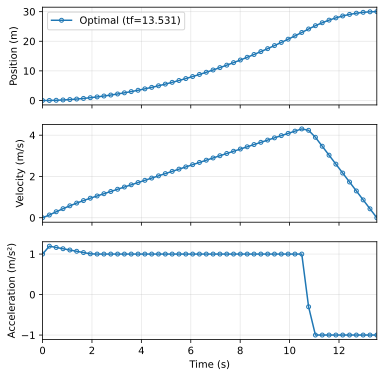

In [93]:
# Visualize results with optimal tf
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(6, 6))
ax1, ax2, ax3 = axes

t_opt = np.linspace(0, optimal_tf, N)

ax1.plot(t_opt, x1.value, '-o', markerfacecolor='none', markersize=4, label=f'Optimal (tf={optimal_tf:.3f})')
ax1.set_ylabel('Position (m)')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(t_opt, x2.value, '-o', markerfacecolor='none', markersize=4)
ax2.set_ylabel('Velocity (m/s)')
ax2.grid(True, alpha=0.3)

ax3.plot(t_opt, u.value, '-o', markerfacecolor='none', markersize=4)

ax3.set_ylabel('Acceleration (m/s²)')
ax3.set_xlabel('Time (s)')
ax3.set_xlim(0, optimal_tf)
ax3.grid(True, alpha=0.3)


plt.show()
